# SSi Highway Survey Analysis
**Road:** A6 Buxton Road, Stockport, Cheshire  
**Survey date:** 29 April 2026  
**Engineer:** M Harris  
**Surface:** Ulltiflex 14 SURF PMB PSV 65  

This notebook analyses ETD (Estimated Texture Depth) and RSE (Road Surface Evenness) measurements along approximately 1km of carriageway.

## 1. Load & Inspect Data

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

with open('SSi_survey_sample.json') as f:
    records = json.load(f)['archive_system_data']

df = pd.DataFrame(records)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date_laid'] = pd.to_datetime(df['date_laid'])

print(f'Total records : {len(df)}')
print(f'Survey types  : {df["survey_type"].unique()}')
print(f'Carriageways  : {df["carriageway"].unique()}')
print(f'Chainage range: {df["chainage"].min()}m – {df["chainage"].max()}m')
print(f'Survey time   : {df["timestamp"].min()} → {df["timestamp"].max()}')
df.head(3)

Matplotlib is building the font cache; this may take a moment.


Total records : 2042
Survey types  : ['ETD' 'RSE']
Carriageways  : ['SB' 'NB']
Chainage range: 0m – 994m
Survey time   : 2026-04-29 11:57:09+00:00 → 2026-04-29 12:03:04+00:00


,id,section,chainage,survey_type,mpd_track_1,mpd_track_2,mpd_track_3,mpd_track_4,ukri_track_1,ukri_track_2,...,job_no,job_description,carriageway,direction,surface_description,date_laid,engineer,client_id,notes,created_timestamp
0,76440,96,960,ETD,None,None,None,None,None,None,...,4214168588,"A6 Buxton Road, Stockport,Cheshire, SK12 2AE",SB,SB,Ulltiflex 14 SURF PMB PSV 65,2026-04-14,M Harris,5,None,2026-05-18T12:24:01.320Z
1,76439,95,950,ETD,None,None,None,None,None,None,...,4214168588,"A6 Buxton Road, Stockport,Cheshire, SK12 2AE",SB,SB,Ulltiflex 14 SURF PMB PSV 65,2026-04-14,M Harris,5,None,2026-05-18T12:24:01.320Z
2,76438,94,940,ETD,None,None,None,None,None,None,...,4214168588,"A6 Buxton Road, Stockport,Cheshire, SK12 2AE",SB,SB,Ulltiflex 14 SURF PMB PSV 65,2026-04-14,M Harris,5,None,2026-05-18T12:24:01.320Z


In [2]:
# Split into ETD and RSE subsets
etd = df[df['survey_type'] == 'ETD'].sort_values('chainage').reset_index(drop=True)
rse = df[df['survey_type'] == 'RSE'].sort_values('chainage').reset_index(drop=True)

rse_nb = rse[rse['carriageway'] == 'NB'].reset_index(drop=True)
rse_sb = rse[rse['carriageway'] == 'SB'].reset_index(drop=True)
etd_nb = etd[etd['carriageway'] == 'NB'].reset_index(drop=True)
etd_sb = etd[etd['carriageway'] == 'SB'].reset_index(drop=True)

print(f'ETD records: {len(etd)} (NB={len(etd_nb)}, SB={len(etd_sb)})')
print(f'RSE records: {len(rse)} (NB={len(rse_nb)}, SB={len(rse_sb)})')

ETD records: 78 (NB=43, SB=35)
RSE records: 1964 (NB=995, SB=969)


## 2. Descriptive Statistics

In [3]:
ETD_MIN = 0.7   # UK minimum texture depth (mm) — skid resistance threshold
RSE_WARN = 1.0  # advisory RSE spike threshold

print('=== ETD (Estimated Texture Depth) — mm ===')
etd_stats = pd.DataFrame({
    'Track 3': etd['etd_track_3'].describe(),
    'Track 4': etd['etd_track_4'].describe()
}).round(3)
print(etd_stats)

print('\n=== RSE (Road Surface Evenness) ===')
rse_stats = pd.DataFrame({
    'NB Track 1': rse_nb['rse_track_1'].describe(),
    'SB Track 1': rse_sb['rse_track_1'].describe()
}).round(4)
print(rse_stats)

=== ETD (Estimated Texture Depth) — mm ===
       Track 3  Track 4
count   78.000   78.000
mean     1.300    1.340
std      0.203    0.224
min      0.620    0.800
25%      1.200    1.220
50%      1.285    1.330
75%      1.398    1.430
max      2.060    2.650

=== RSE (Road Surface Evenness) ===
       NB Track 1  SB Track 1
count    995.0000    969.0000
mean       0.0839      0.0762
std        0.5632      0.5331
min        0.0000      0.0000
25%        0.0000      0.0000
50%        0.0000      0.0000
75%        0.0000      0.0000
max        8.4750      9.5880


## 3. ETD Longitudinal Profile

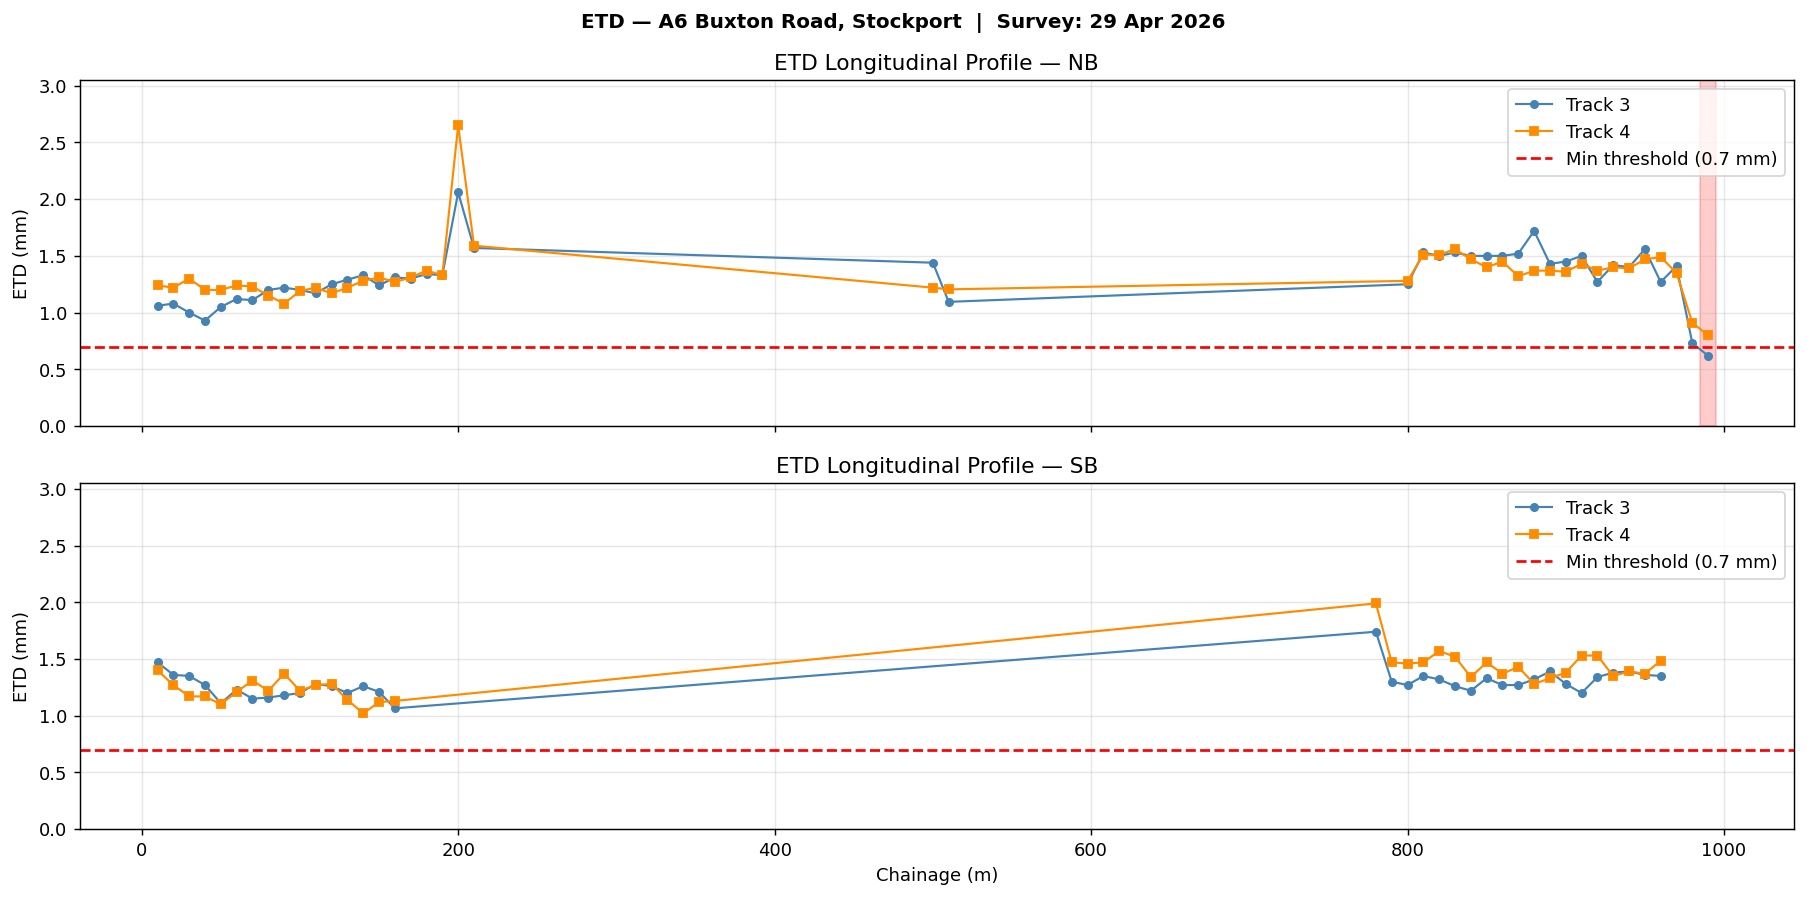

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, cway, sub in zip(axes, ['NB', 'SB'], [etd_nb, etd_sb]):
    ax.plot(sub['chainage'], sub['etd_track_3'], 'o-', ms=4, lw=1.2, label='Track 3', color='steelblue')
    ax.plot(sub['chainage'], sub['etd_track_4'], 's-', ms=4, lw=1.2, label='Track 4', color='darkorange')
    ax.axhline(ETD_MIN, color='red', linestyle='--', lw=1.5, label=f'Min threshold ({ETD_MIN} mm)')
    ax.set_ylabel('ETD (mm)')
    ax.set_title(f'ETD Longitudinal Profile — {cway}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, max(etd['etd_track_3'].max(), etd['etd_track_4'].max()) * 1.15)

    # Shade failing sections
    fail = sub[(sub['etd_track_3'] < ETD_MIN) | (sub['etd_track_4'] < ETD_MIN)]
    for _, row in fail.iterrows():
        ax.axvspan(row['chainage'] - 5, row['chainage'] + 5, alpha=0.2, color='red')

axes[-1].set_xlabel('Chainage (m)')
plt.suptitle('ETD — A6 Buxton Road, Stockport  |  Survey: 29 Apr 2026', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('etd_longitudinal.png', bbox_inches='tight')
plt.show()

## 4. RSE Longitudinal Profile

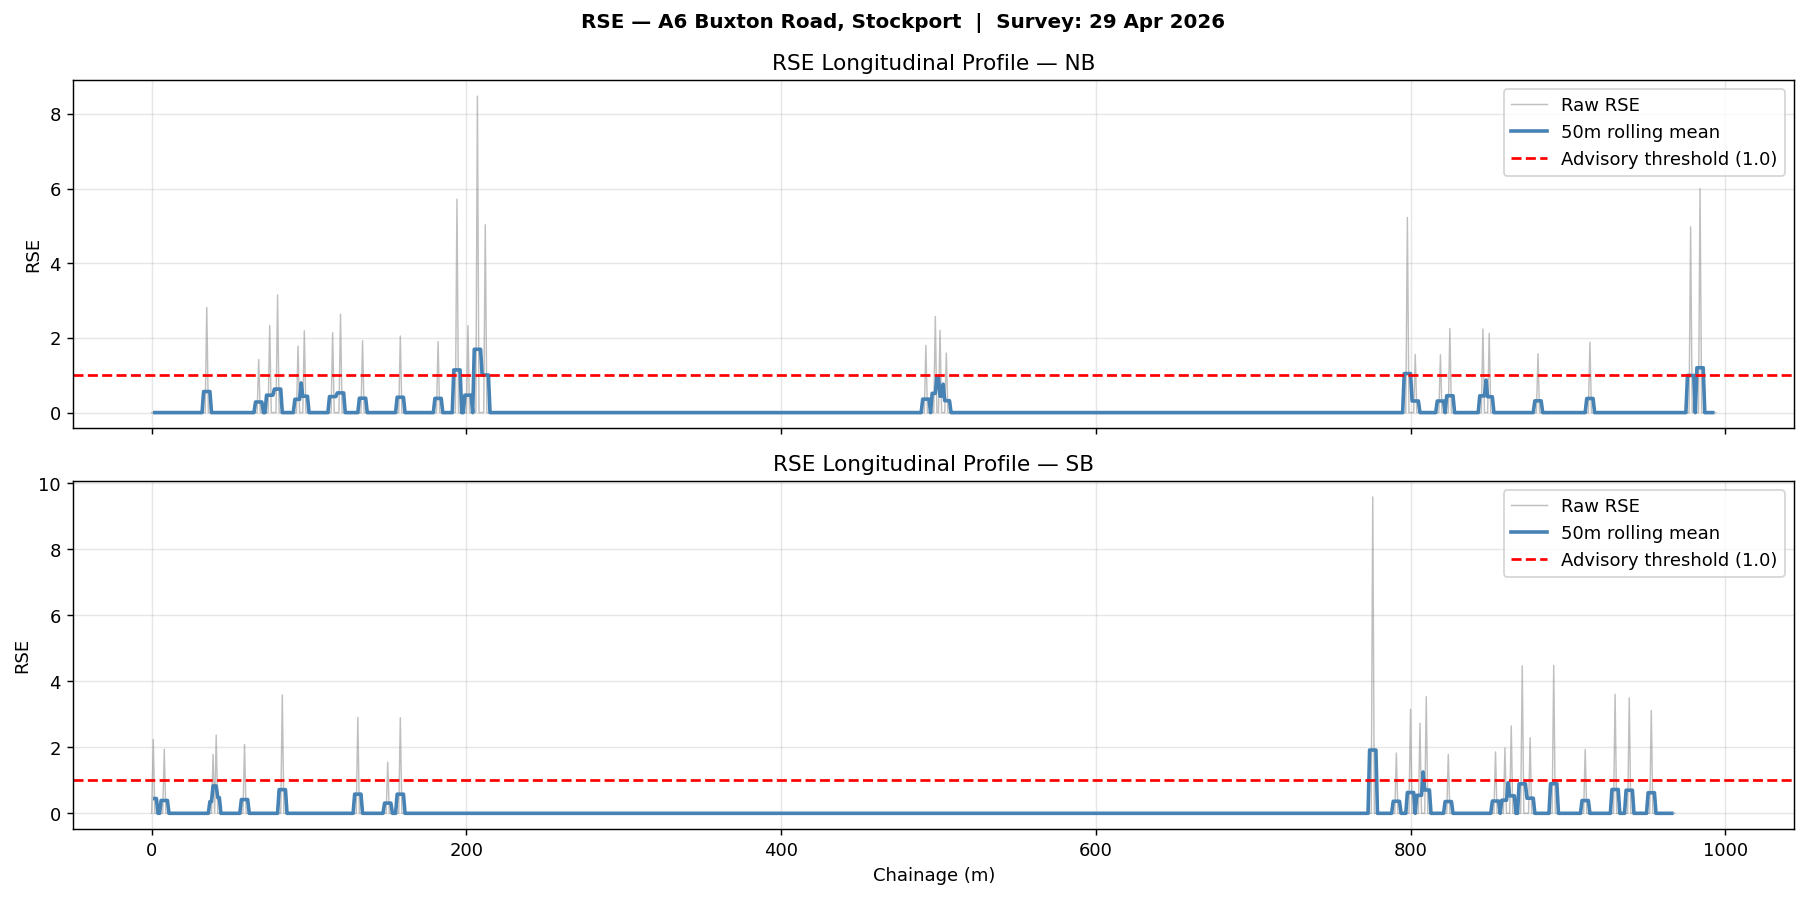

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, cway, sub in zip(axes, ['NB', 'SB'], [rse_nb, rse_sb]):
    # Raw data
    ax.plot(sub['chainage'], sub['rse_track_1'], lw=0.8, color='gray', alpha=0.5, label='Raw RSE')
    # 50m rolling mean (5 readings at 10m spacing)
    rolling = sub.set_index('chainage')['rse_track_1'].rolling(window=5, center=True).mean()
    ax.plot(rolling.index, rolling.values, lw=2, color='steelblue', label='50m rolling mean')
    ax.axhline(RSE_WARN, color='red', linestyle='--', lw=1.5, label=f'Advisory threshold ({RSE_WARN})')
    ax.set_ylabel('RSE')
    ax.set_title(f'RSE Longitudinal Profile — {cway}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Chainage (m)')
plt.suptitle('RSE — A6 Buxton Road, Stockport  |  Survey: 29 Apr 2026', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('rse_longitudinal.png', bbox_inches='tight')
plt.show()

## 5. NB vs SB Comparison

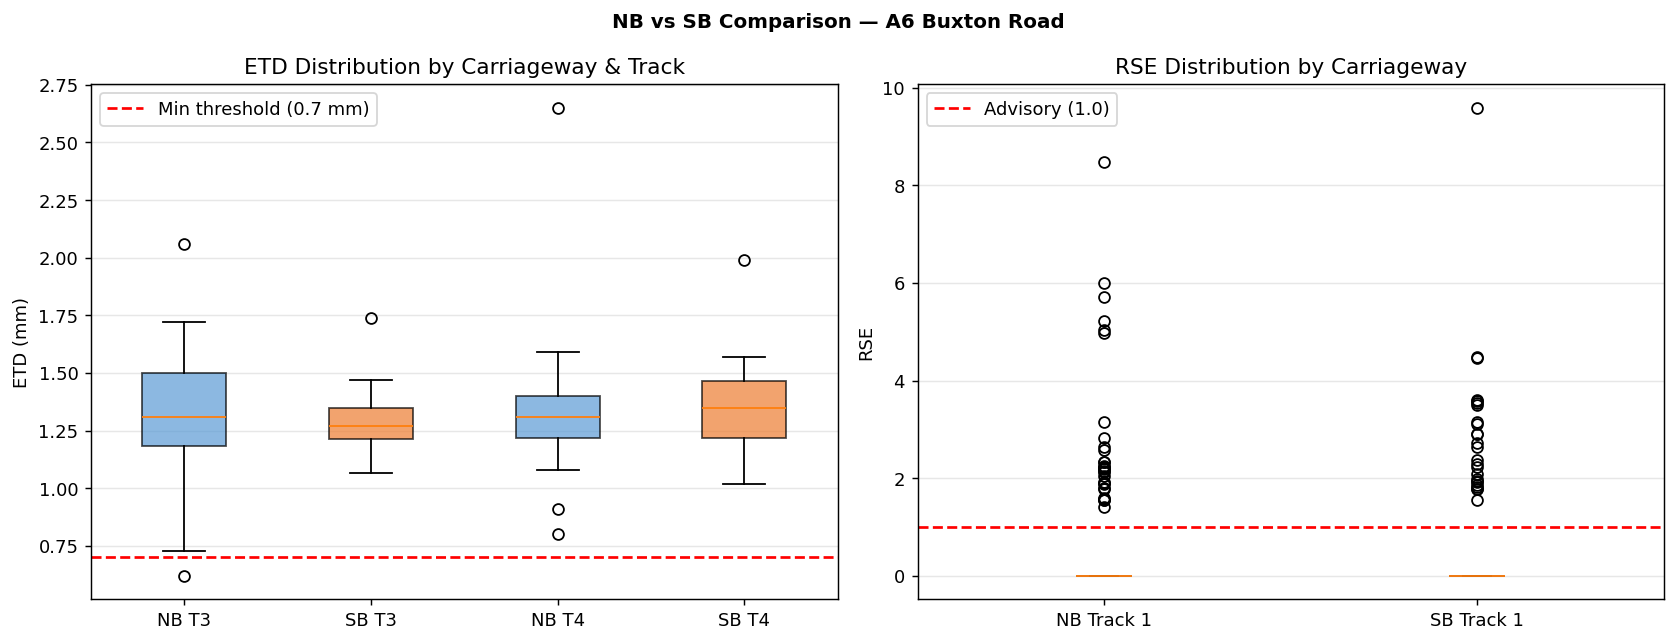

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ETD box comparison
ax = axes[0]
data_to_plot = [
    etd_nb['etd_track_3'].dropna(), etd_sb['etd_track_3'].dropna(),
    etd_nb['etd_track_4'].dropna(), etd_sb['etd_track_4'].dropna()
]
bp = ax.boxplot(data_to_plot, patch_artist=True,
                labels=['NB T3', 'SB T3', 'NB T4', 'SB T4'])
colors = ['#5b9bd5', '#ed7d31', '#5b9bd5', '#ed7d31']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(ETD_MIN, color='red', linestyle='--', label=f'Min threshold ({ETD_MIN} mm)')
ax.set_ylabel('ETD (mm)')
ax.set_title('ETD Distribution by Carriageway & Track')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# RSE box comparison
ax = axes[1]
bp2 = ax.boxplot([rse_nb['rse_track_1'].dropna(), rse_sb['rse_track_1'].dropna()],
                 patch_artist=True, labels=['NB Track 1', 'SB Track 1'])
for patch, color in zip(bp2['boxes'], ['#5b9bd5', '#ed7d31']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(RSE_WARN, color='red', linestyle='--', label=f'Advisory ({RSE_WARN})')
ax.set_ylabel('RSE')
ax.set_title('RSE Distribution by Carriageway')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('NB vs SB Comparison — A6 Buxton Road', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_vs_sb.png', bbox_inches='tight')
plt.show()

## 6. ETD Track 3 vs Track 4 Correlation

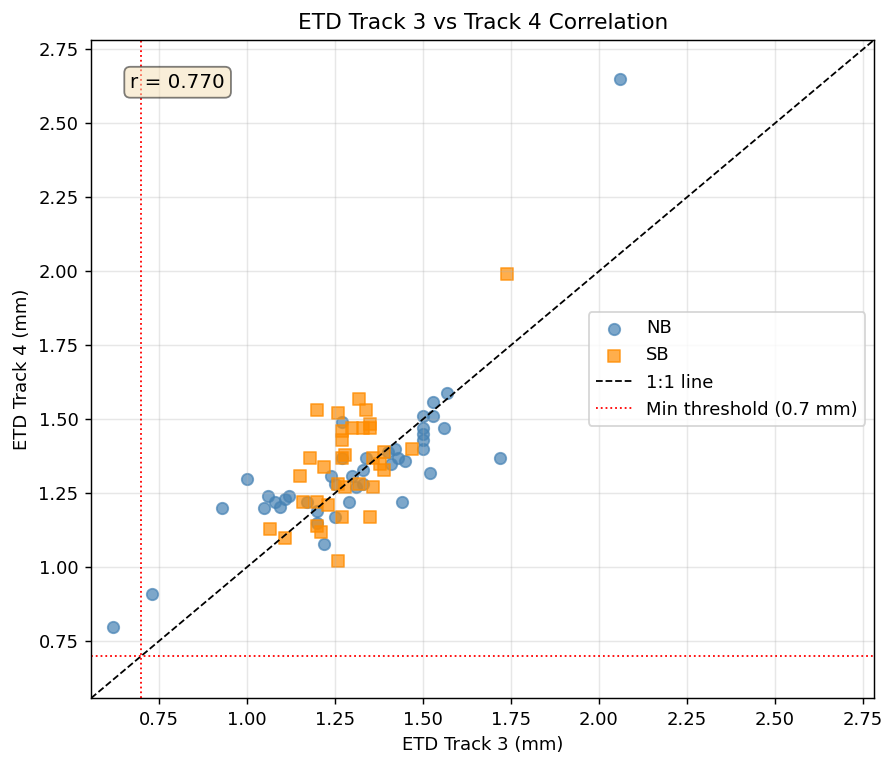

Pearson correlation (Track 3 vs Track 4): 0.7704


In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

for cway, color, marker in [('NB', 'steelblue', 'o'), ('SB', 'darkorange', 's')]:
    sub = etd[etd['carriageway'] == cway]
    ax.scatter(sub['etd_track_3'], sub['etd_track_4'],
               color=color, marker=marker, alpha=0.7, label=cway, s=40)

# Perfect-agreement line
lims = [min(etd['etd_track_3'].min(), etd['etd_track_4'].min()) * 0.9,
        max(etd['etd_track_3'].max(), etd['etd_track_4'].max()) * 1.05]
ax.plot(lims, lims, 'k--', lw=1, label='1:1 line')

# Threshold lines
ax.axvline(ETD_MIN, color='red', linestyle=':', lw=1)
ax.axhline(ETD_MIN, color='red', linestyle=':', lw=1, label=f'Min threshold ({ETD_MIN} mm)')

# Correlation coefficient
valid = etd[['etd_track_3', 'etd_track_4']].dropna()
corr = valid['etd_track_3'].corr(valid['etd_track_4'])
ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
        verticalalignment='top', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('ETD Track 3 (mm)')
ax.set_ylabel('ETD Track 4 (mm)')
ax.set_title('ETD Track 3 vs Track 4 Correlation')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(lims); ax.set_ylim(lims)
plt.tight_layout()
plt.savefig('etd_correlation.png', bbox_inches='tight')
plt.show()

print(f'Pearson correlation (Track 3 vs Track 4): {corr:.4f}')

## 7. Compliance Report — ETD Threshold Failures

In [8]:
fail_mask = (etd['etd_track_3'] < ETD_MIN) | (etd['etd_track_4'] < ETD_MIN)
failures = etd[fail_mask][['carriageway', 'chainage', 'etd_track_3', 'etd_track_4']].copy()
failures.columns = ['Carriageway', 'Chainage (m)', 'ETD Track 3 (mm)', 'ETD Track 4 (mm)']
failures = failures.sort_values(['Carriageway', 'Chainage (m)']).reset_index(drop=True)

total = len(etd)
n_fail = len(failures)
pct_fail = n_fail / total * 100

print(f'ETD Compliance Summary (threshold = {ETD_MIN} mm)')
print(f'  Total ETD readings : {total}')
print(f'  Failing readings   : {n_fail} ({pct_fail:.1f}%)')
print(f'  Pass rate          : {100 - pct_fail:.1f}%')
print()

if n_fail > 0:
    print('Failing sections:')
    print(failures.to_string(index=False))
else:
    print('All sections PASS the ETD threshold.')

ETD Compliance Summary (threshold = 0.7 mm)
  Total ETD readings : 78
  Failing readings   : 1 (1.3%)
  Pass rate          : 98.7%

Failing sections:
Carriageway  Chainage (m)  ETD Track 3 (mm)  ETD Track 4 (mm)
         NB           990              0.62               0.8


## 8. RSE Spike Detection — Worst Locations

In [9]:
rse_mean = rse['rse_track_1'].mean()
rse_std  = rse['rse_track_1'].std()
spike_threshold = rse_mean + 3 * rse_std

spikes = rse[rse['rse_track_1'] > spike_threshold].copy()
spikes = spikes[['carriageway', 'chainage', 'rse_track_1', 'latitude', 'longitude']]
spikes.columns = ['Carriageway', 'Chainage (m)', 'RSE', 'Latitude', 'Longitude']
spikes = spikes.sort_values('RSE', ascending=False).reset_index(drop=True)

print(f'RSE Spike Report (threshold = mean + 3σ = {spike_threshold:.4f})')
print(f'  Overall mean : {rse_mean:.4f}')
print(f'  Overall std  : {rse_std:.4f}')
print(f'  Spike count  : {len(spikes)}')
print()

top10 = spikes.head(10)
print('Top 10 worst RSE locations:')
print(top10.to_string(index=False))

RSE Spike Report (threshold = mean + 3σ = 1.7253)
  Overall mean : 0.0801
  Overall std  : 0.5484
  Spike count  : 48

Top 10 worst RSE locations:
Carriageway  Chainage (m)   RSE  Latitude  Longitude
         SB           776 9.588 53.358290  -2.042539
         NB           207 8.475 53.358273  -2.042649
         NB           984 6.000 53.356710  -2.052914
         NB           194 5.715 53.358300  -2.042478
         NB           798 5.225 53.357082  -2.050457
         NB           212 5.030 53.358265  -2.042715
         NB           978 4.975 53.356720  -2.052834
         SB           891 4.482 53.358550  -2.041000
         SB           871 4.470 53.358505  -2.041268
         SB           930 3.606 53.358640  -2.040478


## 9. Distribution Histograms

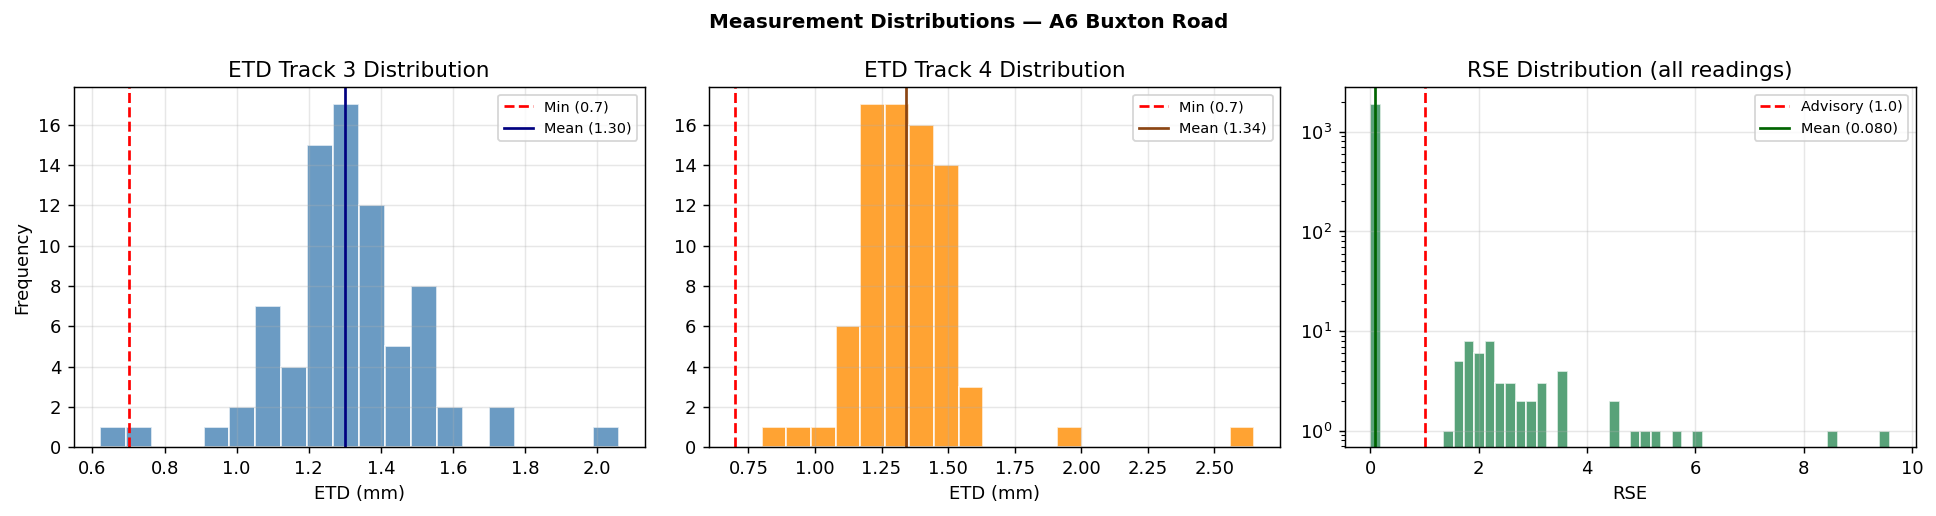

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ETD Track 3
ax = axes[0]
ax.hist(etd['etd_track_3'].dropna(), bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(ETD_MIN, color='red', linestyle='--', label=f'Min ({ETD_MIN})')
ax.axvline(etd['etd_track_3'].mean(), color='navy', linestyle='-', lw=1.5, label=f'Mean ({etd["etd_track_3"].mean():.2f})')
ax.set_xlabel('ETD (mm)'); ax.set_ylabel('Frequency')
ax.set_title('ETD Track 3 Distribution')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ETD Track 4
ax = axes[1]
ax.hist(etd['etd_track_4'].dropna(), bins=20, color='darkorange', alpha=0.8, edgecolor='white')
ax.axvline(ETD_MIN, color='red', linestyle='--', label=f'Min ({ETD_MIN})')
ax.axvline(etd['etd_track_4'].mean(), color='saddlebrown', linestyle='-', lw=1.5, label=f'Mean ({etd["etd_track_4"].mean():.2f})')
ax.set_xlabel('ETD (mm)')
ax.set_title('ETD Track 4 Distribution')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# RSE (log scale to handle spikes)
ax = axes[2]
rse_vals = rse['rse_track_1'].dropna()
ax.hist(rse_vals, bins=50, color='seagreen', alpha=0.8, edgecolor='white')
ax.axvline(RSE_WARN, color='red', linestyle='--', label=f'Advisory ({RSE_WARN})')
ax.axvline(rse_vals.mean(), color='darkgreen', linestyle='-', lw=1.5, label=f'Mean ({rse_vals.mean():.3f})')
ax.set_xlabel('RSE')
ax.set_title('RSE Distribution (all readings)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.suptitle('Measurement Distributions — A6 Buxton Road', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()

## 10. Spatial Map (interactive)

In [11]:
try:
    import folium
    from folium.plugins import HeatMap

    centre_lat = rse['latitude'].mean()
    centre_lon = rse['longitude'].mean()
    m = folium.Map(location=[centre_lat, centre_lon], zoom_start=17,
                   tiles='OpenStreetMap')

    rse_max = rse['rse_track_1'].quantile(0.99)  # cap colour scale at 99th percentile

    def rse_color(val):
        norm = min(val / rse_max, 1.0)
        if norm < 0.33: return 'green'
        if norm < 0.66: return 'orange'
        return 'red'

    # RSE layer
    for _, row in rse.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=3,
            color=rse_color(row['rse_track_1']),
            fill=True, fill_opacity=0.8,
            popup=f"RSE: {row['rse_track_1']:.4f} | Chainage: {row['chainage']}m | {row['carriageway']}"
        ).add_to(m)

    # ETD layer — larger markers, colour by pass/fail
    for _, row in etd.iterrows():
        t3, t4 = row['etd_track_3'], row['etd_track_4']
        passes = (pd.notna(t3) and t3 >= ETD_MIN) and (pd.notna(t4) and t4 >= ETD_MIN)
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=6,
            color='blue' if passes else 'red',
            fill=True, fill_opacity=0.9,
            popup=f"ETD T3: {t3:.2f}mm  T4: {t4:.2f}mm | {'PASS' if passes else 'FAIL'} | {row['carriageway']}"
        ).add_to(m)

    # Legend
    legend_html = '''
    <div style="position:fixed; bottom:30px; left:30px; z-index:1000;
                background:white; padding:10px; border:2px solid grey; border-radius:5px; font-size:12px">
        <b>RSE</b><br>
        <span style="color:green">&#9679;</span> Low (good)<br>
        <span style="color:orange">&#9679;</span> Medium<br>
        <span style="color:red">&#9679;</span> High (defect)<br><br>
        <b>ETD</b> (larger dots)<br>
        <span style="color:blue">&#9679;</span> PASS (&ge;0.7mm)<br>
        <span style="color:red">&#9679;</span> FAIL (&lt;0.7mm)
    </div>'''
    m.get_root().html.add_child(folium.Element(legend_html))

    m.save('survey_map.html')
    print('Map saved to survey_map.html — open it in a browser to explore interactively.')
    display(m)

except ImportError:
    print('folium not installed. Run: pip install folium')

Map saved to survey_map.html — open it in a browser to explore interactively.


## 11. Executive Summary

In [12]:
n_etd_total = len(etd)
n_etd_fail  = len(failures)
n_rse_spikes = len(spikes)
etd_mean_t3 = etd['etd_track_3'].mean()
etd_mean_t4 = etd['etd_track_4'].mean()
rse_mean_nb = rse_nb['rse_track_1'].mean()
rse_mean_sb = rse_sb['rse_track_1'].mean()

print('=' * 60)
print('EXECUTIVE SUMMARY')
print('A6 Buxton Road, Stockport | Survey: 29 Apr 2026')
print('=' * 60)
print(f'\nSurface: Ulltiflex 14 SURF PMB PSV 65')
print(f'Route length surveyed: ~{etd["chainage"].max()}m')
print(f'\nETD (Estimated Texture Depth)')
print(f'  Mean Track 3 : {etd_mean_t3:.3f} mm')
print(f'  Mean Track 4 : {etd_mean_t4:.3f} mm')
print(f'  Sections failing 0.7mm threshold: {n_etd_fail}/{n_etd_total} ({n_etd_fail/n_etd_total*100:.1f}%)')
print(f'  Overall compliance: {"PASS" if n_etd_fail == 0 else "INVESTIGATE"}')
print(f'\nRSE (Road Surface Evenness)')
print(f'  NB mean : {rse_mean_nb:.4f}')
print(f'  SB mean : {rse_mean_sb:.4f}')
print(f'  Spike locations (>3σ): {n_rse_spikes}')
print(f'  Smoothness assessment: {"Excellent" if rse_mean_nb < 0.1 and rse_mean_sb < 0.1 else "Good" if rse_mean_nb < 0.5 else "Review required"}')
print('\nOutputs:')
print('  etd_longitudinal.png, rse_longitudinal.png, nb_vs_sb.png')
print('  etd_correlation.png, distributions.png, survey_map.html')
print('=' * 60)

EXECUTIVE SUMMARY
A6 Buxton Road, Stockport | Survey: 29 Apr 2026

Surface: Ulltiflex 14 SURF PMB PSV 65
Route length surveyed: ~990m

ETD (Estimated Texture Depth)
  Mean Track 3 : 1.300 mm
  Mean Track 4 : 1.340 mm
  Sections failing 0.7mm threshold: 1/78 (1.3%)
  Overall compliance: INVESTIGATE

RSE (Road Surface Evenness)
  NB mean : 0.0839
  SB mean : 0.0762
  Spike locations (>3σ): 48
  Smoothness assessment: Excellent

Outputs:
  etd_longitudinal.png, rse_longitudinal.png, nb_vs_sb.png
  etd_correlation.png, distributions.png, survey_map.html
